<a href="https://colab.research.google.com/github/silvia-dev-prog/ai-agents-for-beginners/blob/main/Modulo_8_Aula3_Sintonia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Técnicas de Inteligência Artificial Aplicadas às Engenharias de Processos**

04 de fevereiro de 2026 | Extensão FEQ UNICAMP

Professor: Vitor Oliveira

## Módulo 8 - Aula 3 | Características e Sintonia de Controladores Fuzzy

In [ ]:
!pip install scikit-fuzzy

In [ ]:
## Importando as dependências
import numpy as np
import pandas as pd
from scipy.optimize import fsolve
from sympy import symbols, Eq, solve
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from scipy.integrate import odeint
from simple_pid import PID
plt.rcParams['figure.figsize'] = 25,5

### Montagem do Sistema de Inferência Fuzzy

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/skfuzzy/control/fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


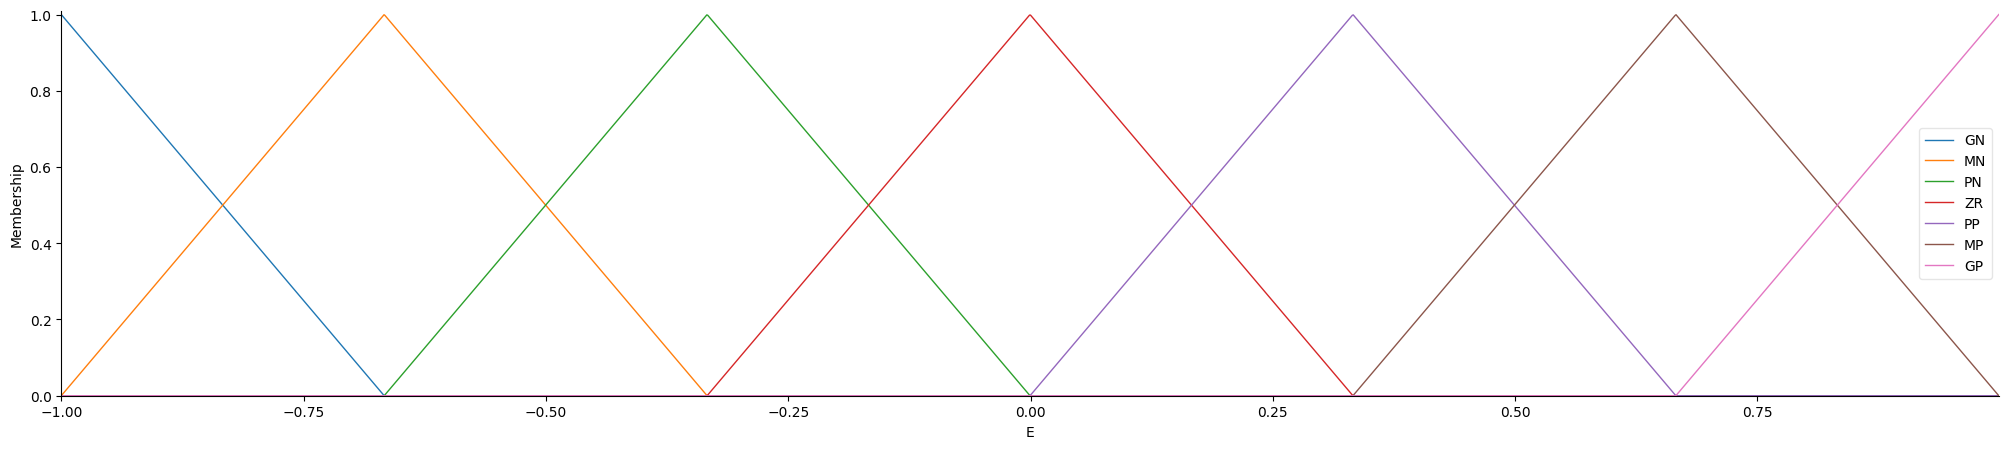

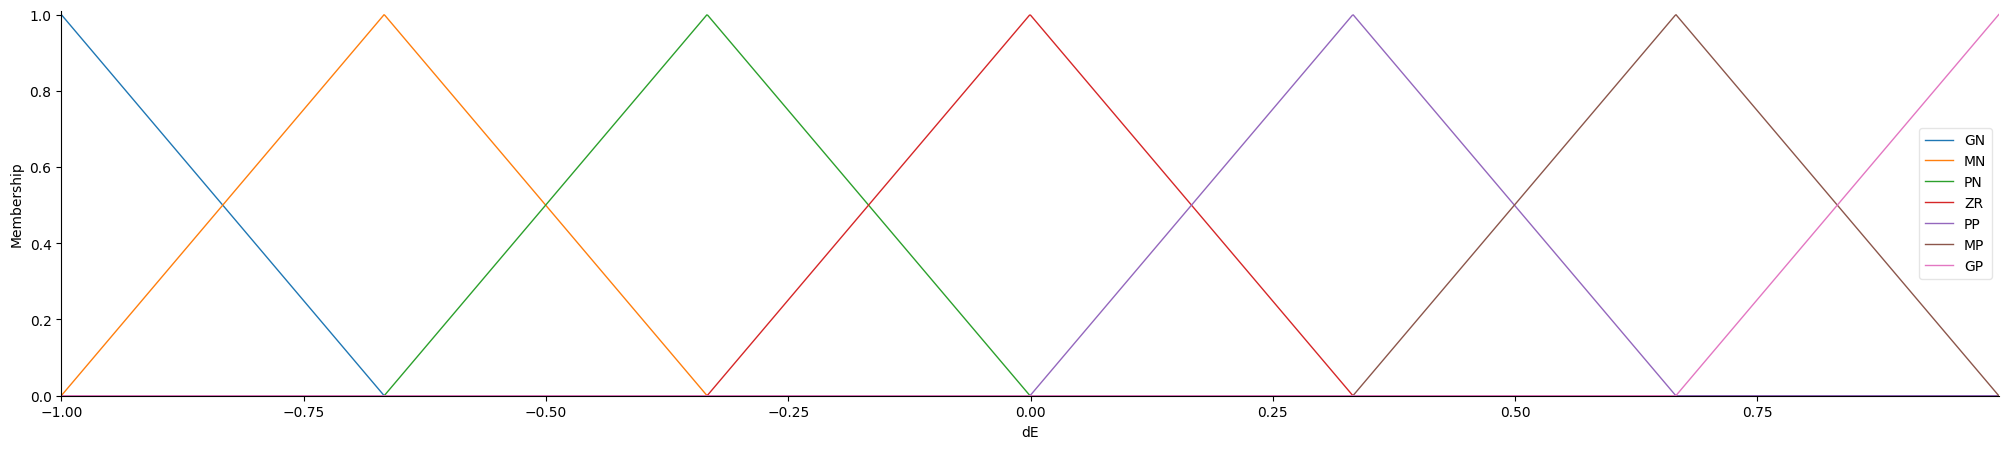

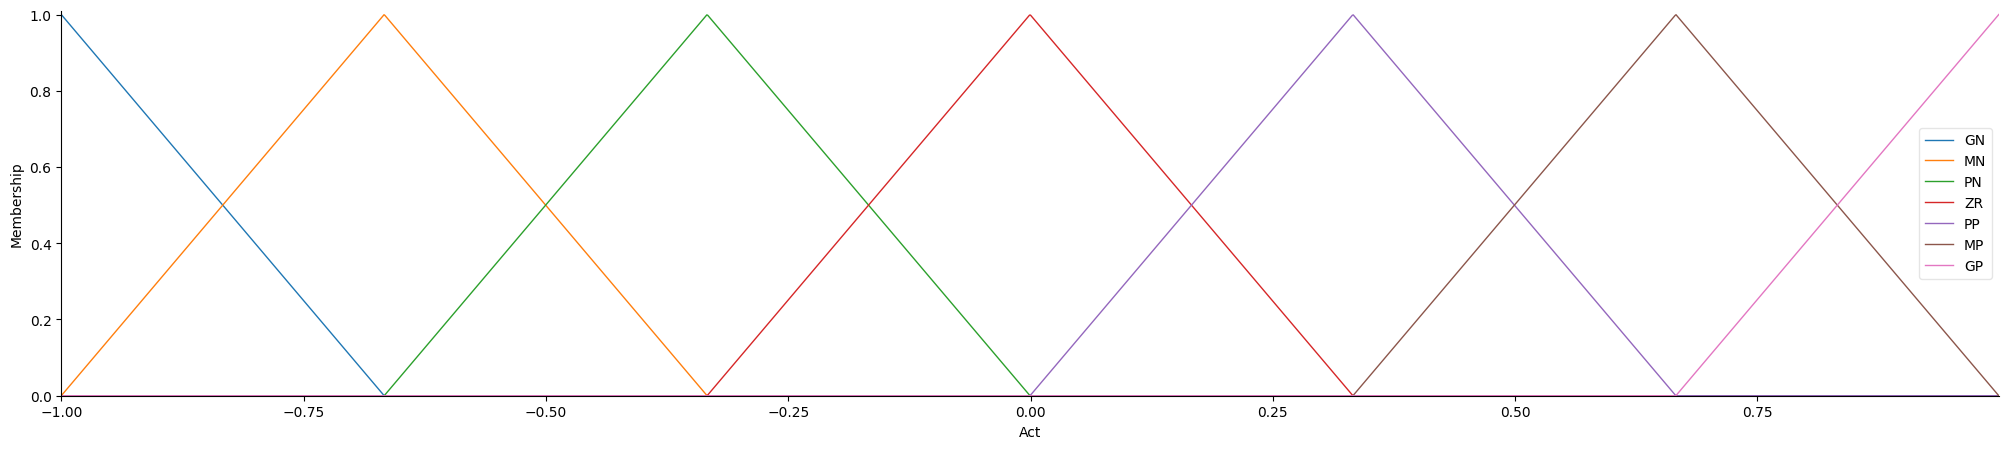

In [ ]:
#Definindo inputs e outputs
input1 = ctrl.Antecedent(np.arange(-1, 1, 0.001), 'E') #Erro
input2 = ctrl.Antecedent(np.arange(-1, 1, 0.001), 'dE') #Variação do erro
output = ctrl.Consequent(np.arange(-1, 1, 0.001), 'Act', defuzzify_method='centroid') #Variação da ação de controle

#Definição dos fuzzy sets
input1.automf(names=['GN','MN','PN','ZR','PP', 'MP', 'GP'])
input2.automf(names=['GN','MN','PN','ZR','PP', 'MP', 'GP'])
output.automf(names=['GN','MN','PN','ZR','PP', 'MP', 'GP'])

input1.view()
input2.view()
output.view()

rules = [] #organização do conjunto de regras em uma lista

#Coluna GN
rules.append(ctrl.Rule(input1['GN'] & input2['GP'], output['PN']))
rules.append(ctrl.Rule(input1['GN'] & input2['MP'], output['MN']))
rules.append(ctrl.Rule(input1['GN'] & input2['PP'], output['GN']))
rules.append(ctrl.Rule(input1['GN'] & (input2['ZR'] | input2['PN'] | input2['MN']| input2['GN']), output['GN']))

#Coluna MN
rules.append(ctrl.Rule(input1['MN'] & input2['GP'], output['ZR']))
rules.append(ctrl.Rule(input1['MN'] & input2['MP'], output['PN']))
rules.append(ctrl.Rule(input1['MN'] & input2['PP'], output['MN']))
rules.append(ctrl.Rule(input1['MN'] & input2['ZR'], output['GN']))
rules.append(ctrl.Rule(input1['MN'] & (input2['PN'] | input2['MN']| input2['GN']), output['GN']))

#Coluna PN
rules.append(ctrl.Rule(input1['PN'] & input2['GP'], output['PP']))
rules.append(ctrl.Rule(input1['PN'] & input2['MP'], output['ZR']))
rules.append(ctrl.Rule(input1['PN'] & input2['PP'], output['PN']))
rules.append(ctrl.Rule(input1['PN'] & input2['ZR'], output['MN']))
rules.append(ctrl.Rule(input1['PN'] & input2['PN'], output['GN']))
rules.append(ctrl.Rule(input1['PN'] & (input2['MN']| input2['GN']), output['GN']))

#Coluna ZR
rules.append(ctrl.Rule(input1['ZR'] & input2['GP'], output['GP']))
rules.append(ctrl.Rule(input1['ZR'] & input2['MP'], output['MP']))
rules.append(ctrl.Rule(input1['ZR'] & input2['PP'], output['PP']))
rules.append(ctrl.Rule(input1['ZR'] & input2['ZR'], output['ZR']))
rules.append(ctrl.Rule(input1['ZR'] & input2['PN'], output['PN']))
rules.append(ctrl.Rule(input1['ZR'] & input2['MN'], output['MN']))
rules.append(ctrl.Rule(input1['ZR'] & input2['GN'], output['GN']))

#Coluna PP
rules.append(ctrl.Rule(input1['PP'] & (input2['GP'] | input2['MP']), output['GP']))
rules.append(ctrl.Rule(input1['PP'] & input2['PP'], output['MP']))
rules.append(ctrl.Rule(input1['PP'] & input2['ZR'], output['PP']))
rules.append(ctrl.Rule(input1['PP'] & input2['PN'], output['ZR']))
rules.append(ctrl.Rule(input1['PP'] & input2['MN'], output['PN']))
rules.append(ctrl.Rule(input1['PP'] & input2['GN'], output['MN']))

#Coluna MP
rules.append(ctrl.Rule(input1['MP'] & (input2['GP'] | input2['MP'] | input2['PP']), output['GP']))
rules.append(ctrl.Rule(input1['MP'] & input2['ZR'], output['MP']))
rules.append(ctrl.Rule(input1['MP'] & input2['PN'], output['PP']))
rules.append(ctrl.Rule(input1['MP'] & input2['MN'], output['ZR']))
rules.append(ctrl.Rule(input1['MP'] & input2['GN'], output['PN']))

#Coluna GP
rules.append(ctrl.Rule(input1['GP'] & (input2['GP'] | input2['MP'] | input2['PP']| input2['ZR']), output['GP']))
rules.append(ctrl.Rule(input1['GP'] & input2['PN'], output['MP']))
rules.append(ctrl.Rule(input1['GP'] & input2['MN'], output['PP']))
rules.append(ctrl.Rule(input1['GP'] & input2['GN'], output['ZR']))

#Sistema de inferência
controller = ctrl.ControlSystem(rules)
#Simulador
controller_sim = ctrl.ControlSystemSimulation(controller)

### Aplicação em Controle de um Processo de Tratamento de Água

In [ ]:
# ==================== MODELO DE TRATAMENTO DE ÁGUA ====================
"""
Processo de Coagulação/Floculação em ETA (Estação de Tratamento de Água)

Variáveis:
- T: Turbidez da água tratada [NTU] - variável controlada (PV)
- Floc: Concentração de flocos formados [mg/L]
- Dose: Dosagem de coagulante (sulfato de alumínio) [mg/L] - variável manipulada (MV)
- T_in: Turbidez da água bruta [NTU] - distúrbio
- Q: Vazão de entrada [m³/h] - distúrbio secundário
"""

'\nProcesso de Coagulação/Floculação em ETA (Estação de Tratamento de Água)\n\nVariáveis:\n- T: Turbidez da água tratada [NTU] - variável controlada (PV)\n- Floc: Concentração de flocos formados [mg/L]\n- Dose: Dosagem de coagulante (sulfato de alumínio) [mg/L] - variável manipulada (MV)\n- T_in: Turbidez da água bruta [NTU] - distúrbio\n- Q: Vazão de entrada [m³/h] - distúrbio secundário\n'

In [ ]:
default_params_eta = {
    'k_coag': 0.8,      # Eficiência de coagulação [1/(mg/L)]
    'k_floc': 0.5,      # Taxa de formação de flocos [1/h]
    'k_sed': 0.3,       # Taxa de sedimentação [1/h]
    'k_rem': 2.0,       # Taxa de remoção de turbidez [NTU*L/(mg*h)]
    'K_sat': 10.0,      # Constante de saturação [NTU]
    'V': 500.0,         # Volume do tanque de floculação [m³]
    'pH_opt': 6.5,      # pH ótimo para coagulação
    'T_max': 100.0,     # Turbidez máxima esperada [NTU]
}

In [ ]:
# Limites da variável manipulada
DOSE_MIN = 5.0      # mg/L - dosagem mínima de coagulante
DOSE_MAX = 80.0     # mg/L - dosagem máxima de coagulante

In [ ]:
def eficiencia_coagulacao(Dose, T, params):
    """
    Calcula a eficiência de remoção de turbidez baseada na dosagem de coagulante.

    Modelo de Langmuir modificado para coagulação:
    Eff = k_rem * Dose * T / (K_sat + T)
    """
    T = max(T, 0.0)
    Dose = max(Dose, 0.0)

    # Termo de saturação (eficiência diminui com baixa turbidez)
    sat_term = T / (params['K_sat'] + T)

    # Taxa de remoção
    removal_rate = params['k_rem'] * Dose * sat_term

    return removal_rate

In [ ]:
def model_equations_eta(state, t, params, Q_in, T_in, Dose):
    """
    Sistema de EDOs do processo de tratamento de água.

    Parameters
    ----------
    state : array
        [T, Floc]
        T: Turbidez da água [NTU]
        Floc: Concentração de flocos [mg/L]
    t : float
        Tempo [horas]
    params : dict
        Parâmetros do modelo
    Q_in : float or callable
        Vazão de entrada [m³/h]
    T_in : float or callable
        Turbidez da água bruta [NTU]
    Dose : float or callable
        Dosagem de coagulante [mg/L]

    Returns
    -------
    list
        [dT/dt, dFloc/dt]
    """
    T, Floc = state

    # Permite entrada variável no tempo
    Q = Q_in(t) if callable(Q_in) else Q_in
    Tin = T_in(t) if callable(T_in) else T_in
    D = Dose(t) if callable(Dose) else Dose

    # Taxa de diluição
    dilution = Q / params['V']

    # Eficiência de remoção
    removal = eficiencia_coagulacao(D, T, params)

    # Garante valores não negativos
    T = max(T, 0.0)
    Floc = max(Floc, 0.0)
    D = max(D, 0.0)

    # Equações diferenciais
    # Balanço de turbidez
    dT_dt = dilution * (Tin - T) - removal

    # Formação e sedimentação de flocos
    dFloc_dt = params['k_floc'] * D * T - params['k_sed'] * Floc

    return [dT_dt, dFloc_dt]

In [ ]:
# ==================== SIMULAÇÃO COM CONTROLE ====================
def simular_eta_com_controle():
    """Simula a ETA com controlador fuzzy."""

    # Condições iniciais
    T0 = 15.0    # Turbidez inicial [NTU]
    Floc0 = 0.0  # Flocos iniciais [mg/L]
    IC = [T0, Floc0]

    # Setpoint
    T_sp = 2.0  # NTU - Turbidez desejada (padrão potabilidade: < 5 NTU)
    T_max = 20.0  # NTU - Turbidez máxima esperada

    # Ganhos do controlador
    Ke = 4
    K0 = 4
    K1 = 2
    Kd = 2

    # Inicialização do controlador
    PI = 8.0      # Dosagem inicial [mg/L]
    PD = 0.0

    # Parâmetros de tempo e simulação
    ti = 0.0
    tf = 96.0    # horas (4 dias)
    dt = 0.05    # horas (3 minutos)

    # Inicialização do erro
    erro_fuzzy = [T_sp - T0] * 2

    # Função de saturação
    def sat(dose):
        return max(DOSE_MIN, min(DOSE_MAX, dose))

    # Distúrbios: Vazão e Turbidez de entrada
    def Q_in_disturbio(t):
        """Vazão de entrada [m³/h]"""
        # Vazão base com variação diária
        Q_base = 200.0
        variacao = 50.0 * np.sin(2 * np.pi * t / 24)  # Ciclo de 24h
        return Q_base + variacao

    def T_in_disturbio(t):
        """Turbidez da água bruta [NTU]"""
        # Cenário: Chuva entre t=15h e t=20h causando aumento de turbidez
        if t < 15:
            return 40.0  # Turbidez normal
        elif t < 20:
            return 40.0 + 30.0 * (t - 15) / 5  # Aumento gradual (chuva)
        elif t < 25:
            return 70.0  # Turbidez alta mantida
        else:
            return 40.0  # Retorno à normalidade

    # Armazenamento de dados
    log = []

    # Estado atual
    state = IC.copy()

    # Laço de controle
    time_points = np.arange(ti, tf + dt, dt)

    for i, t in enumerate(time_points):
        T, Floc = state

        # Adicionar ruído de medição realista
        T_medido = T + np.random.normal(0, 0.1)  # Ruído do turbidímetro

        # Calcular erro
        erro_atual = T_sp - T_medido

        #Se erro arredondado for zero, printar tempo em que isso aconteceu
        if round(erro_atual, 1) == 0.0:
            print(f"Erro zero atingido em t = {t:.2f} horas")

        # print(erro_atual)
        erro_fuzzy.append(erro_atual)

        #Normalizar os valores de entrada do controlador fuzzy
        erro_norm = erro_fuzzy[-1]/(T_max - T_sp)
        erro_norm_ant = erro_fuzzy[-2]/(T_max - T_sp)
        dE_norm = (erro_norm - erro_norm_ant) / dt

        # Calcular ação de controle fuzzy
        try:
            controller_sim.input['E'] = erro_norm * Ke
            controller_sim.input['dE'] = dE_norm * Kd
            controller_sim.compute()
            dU_fuzzy = controller_sim.output['Act']
        except:
            dU_fuzzy = 0.0

        # Calcular sinal de controle PID
        PI = -dU_fuzzy * K0 + PI  # Nota: sinal positivo para aumentar dose
        PD = -dU_fuzzy * K1
        PID = PI + PD

        # Aplicar saturação na dosagem (variável manipulada)
        Dose_atual = sat(PID)

        # Obter os distúrbios no tempo atual
        Q_atual = Q_in_disturbio(t)
        T_in_atual = T_in_disturbio(t)

        # Registrar dados
        log.append([t, T, Floc, T_medido, Dose_atual, Q_atual, T_in_atual,
                   erro_atual, dU_fuzzy, PI, PD])

        # Simular um passo de tempo
        if i < len(time_points) - 1:
            t_span = [t, t + dt]
            sol = odeint(model_equations_eta, state, t_span, args=(default_params_eta, Q_atual, T_in_atual, Dose_atual))
            state = sol[-1, :]  # Atualizar estado

            # Evitar crescimento descontrolado
            state[0] = max(state[0], 0.0)
            state[1] = max(state[1], 0.0)

    return np.array(log)

In [ ]:
# ==================== VISUALIZAÇÃO ====================
def plotar_resultados_eta(log):
    """Plota os resultados da simulação da ETA."""

    t = log[:, 0]
    T = log[:, 1]          # Turbidez tratada
    Floc = log[:, 2]       # Flocos
    T_medido = log[:, 3]   # Turbidez medida
    Dose = log[:, 4]       # Dosagem (MV)
    Q_in = log[:, 5]       # Vazão (distúrbio)
    T_in = log[:, 6]       # Turbidez entrada (distúrbio)
    erro = log[:, 7]

    fig, axes = plt.subplots(6, 1, figsize=(14, 14))

    # Gráfico 1: Turbidez tratada (variável controlada)
    axes[0].plot(t, T, 'b-', linewidth=2, label='Turbidez tratada (T)')
    axes[0].plot(t, T_medido, 'b.', markersize=1, alpha=0.3, label='T medido')
    axes[0].axhline(y=2.0, color='r', linestyle='--', linewidth=1.5, label='Setpoint (2 NTU)')
    axes[0].axhline(y=5.0, color='orange', linestyle=':', linewidth=1, label='Limite potabilidade')
    axes[0].fill_between(t, 0, 5, alpha=0.1, color='green')
    axes[0].set_ylabel('Turbidez [NTU]')
    axes[0].legend(loc='best', fontsize=9)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_title('Controle Fuzzy de ETA - Remoção de Turbidez', fontsize=12, fontweight='bold')

    # Gráfico 2: Dosagem de coagulante (MV)
    axes[1].plot(t, Dose, 'g-', linewidth=2, label='Dosagem coagulante (MV)')
    axes[1].axhline(y=DOSE_MIN, color='r', linestyle=':', linewidth=1, alpha=0.5)
    axes[1].axhline(y=DOSE_MAX, color='r', linestyle=':', linewidth=1, alpha=0.5)
    axes[1].fill_between(t, DOSE_MIN, DOSE_MAX, alpha=0.1, color='gray')
    axes[1].set_ylabel('Dosagem [mg/L]')
    axes[1].legend(loc='best', fontsize=9)
    axes[1].grid(True, alpha=0.3)

    # Gráfico 3: Turbidez de entrada (distúrbio principal)
    axes[2].plot(t, T_in, 'brown', linewidth=2, label='Turbidez bruta (distúrbio)', linestyle='--')
    axes[2].fill_between(t, 0, T_in, alpha=0.2, color='brown')
    axes[2].set_ylabel('Turbidez entrada [NTU]')
    axes[2].legend(loc='best', fontsize=9)
    axes[2].grid(True, alpha=0.3)
    axes[2].set_title('Distúrbios do Processo', fontsize=10)

    # Gráfico 4: Vazão de entrada (distúrbio secundário)
    axes[3].plot(t, Q_in, 'purple', linewidth=2, label='Vazão entrada', linestyle='-.')
    axes[3].set_ylabel('Vazão [m³/h]')
    axes[3].legend(loc='best', fontsize=9)
    axes[3].grid(True, alpha=0.3)

    # Gráfico 5: Concentração de flocos
    axes[4].plot(t, Floc, 'orange', linewidth=2, label='Concentração de flocos')
    axes[4].set_ylabel('Flocos [mg/L]')
    axes[4].legend(loc='best', fontsize=9)
    axes[4].grid(True, alpha=0.3)

    # Gráfico 6: Erro de controle
    axes[5].plot(t, erro, 'r-', linewidth=2, label='Erro (Tsp - T)')
    axes[5].axhline(y=0, color='k', linestyle='--', linewidth=1)
    axes[5].fill_between(t, -0.5, 0.5, alpha=0.2, color='green', label='Banda ±0.5 NTU')
    axes[5].set_ylabel('Erro [NTU]')
    axes[5].set_xlabel('Tempo [horas]')
    axes[5].legend(loc='best', fontsize=9)
    axes[5].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('controle_fuzzy_eta.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Calcular métricas de desempenho
    print("\n" + "="*70)
    print("MÉTRICAS DE DESEMPENHO - CONTROLE DE ETA")
    print("="*70)

    # Verificar conformidade com padrão de potabilidade
    tempo_fora_padrao = np.sum(T > 5.0) * (t[1] - t[0])
    percent_conformidade = (1 - tempo_fora_padrao / t[-1]) * 100

    # Após regime (últimos 50% do tempo)
    idx_regime = int(0.5 * len(t))

    ISE = np.sum(erro**2) * (t[1] - t[0])
    IAE = np.sum(np.abs(erro)) * (t[1] - t[0])

    erro_regime = erro[idx_regime:]
    media_regime = np.mean(np.abs(erro_regime))
    std_regime = np.std(erro_regime)

    # Consumo de coagulante
    consumo_total = np.mean(Dose) * np.mean(Q_in) * t[-1] / 1000  # kg

    print(f"Turbidez média final:                 {np.mean(T[idx_regime:]):.2f} NTU")
    print(f"Conformidade c/ padrão (< 5 NTU):     {percent_conformidade:.1f} %")
    print(f"Tempo fora do padrão:                 {tempo_fora_padrao:.2f} horas")
    print(f"\nISE (Integral Squared Error):         {ISE:.2f}")
    print(f"IAE (Integral Absolute Error):        {IAE:.2f}")
    print(f"Erro médio em regime:                 {media_regime:.3f} NTU")
    print(f"Desvio padrão do erro em regime:      {std_regime:.3f} NTU")
    print(f"\nDosagem média:                        {np.mean(Dose):.2f} mg/L")
    print(f"Variação de dosagem:                  {Dose.min():.2f} - {Dose.max():.2f} mg/L")
    print(f"Consumo estimado de coagulante:       {consumo_total:.1f} kg")
    print(f"\nEficiência de remoção média:          {(1 - np.mean(T)/np.mean(T_in))*100:.1f} %")
    print("="*70)

SIMULAÇÃO DE ETA COM CONTROLE FUZZY

Processo: Coagulação/Floculação
Variável Controlada (PV): Turbidez da água tratada [NTU]
Variável Manipulada (MV): Dosagem de coagulante [mg/L]
Distúrbios: Turbidez e vazão da água bruta
Setpoint: 2.0 NTU (padrão potabilidade: < 5.0 NTU)

Iniciando simulação...

Erro zero atingido em t = 2.40 horas
Erro zero atingido em t = 3.10 horas
Erro zero atingido em t = 3.55 horas
Erro zero atingido em t = 3.80 horas
Erro zero atingido em t = 4.15 horas
Erro zero atingido em t = 4.20 horas
Erro zero atingido em t = 4.55 horas
Erro zero atingido em t = 4.60 horas
Erro zero atingido em t = 4.80 horas
Erro zero atingido em t = 5.10 horas
Erro zero atingido em t = 5.15 horas
Erro zero atingido em t = 5.50 horas
Erro zero atingido em t = 5.80 horas
Erro zero atingido em t = 5.85 horas
Erro zero atingido em t = 5.90 horas
Erro zero atingido em t = 6.00 horas
Erro zero atingido em t = 6.10 horas
Erro zero atingido em t = 6.35 horas
Erro zero atingido em t = 6.55 hor

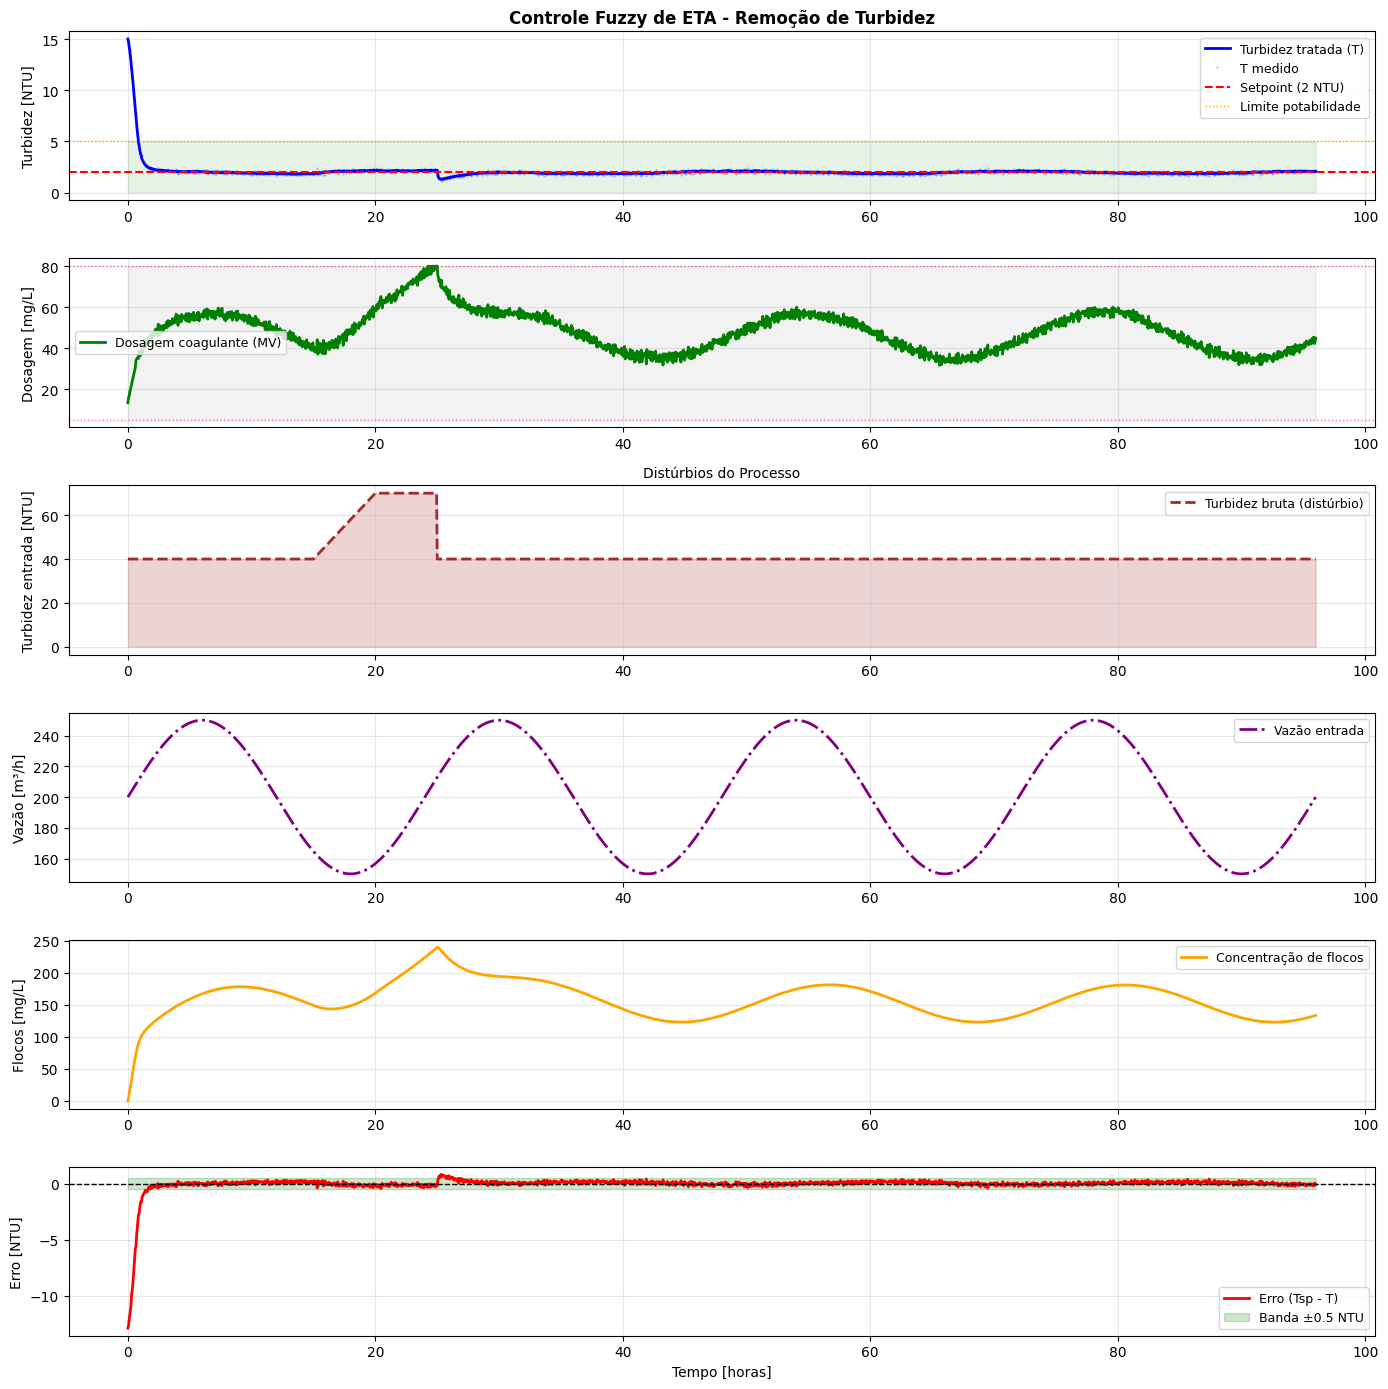


MÉTRICAS DE DESEMPENHO - CONTROLE DE ETA
Turbidez média final:                 1.98 NTU
Conformidade c/ padrão (< 5 NTU):     99.1 %
Tempo fora do padrão:                 0.90 horas

ISE (Integral Squared Error):         74.67
IAE (Integral Absolute Error):        20.15
Erro médio em regime:                 0.109 NTU
Desvio padrão do erro em regime:      0.134 NTU

Dosagem média:                        48.26 mg/L
Variação de dosagem:                  13.28 - 80.00 mg/L
Consumo estimado de coagulante:       926.5 kg

Eficiência de remoção média:          95.1 %


In [ ]:
# ==================== EXECUÇÃO ====================
if __name__ == "__main__":
    print("="*70)
    print("SIMULAÇÃO DE ETA COM CONTROLE FUZZY")
    print("="*70)
    print("\nProcesso: Coagulação/Floculação")
    print("Variável Controlada (PV): Turbidez da água tratada [NTU]")
    print("Variável Manipulada (MV): Dosagem de coagulante [mg/L]")
    print("Distúrbios: Turbidez e vazão da água bruta")
    print("Setpoint: 2.0 NTU (padrão potabilidade: < 5.0 NTU)")
    print("\nIniciando simulação...\n")

    log = simular_eta_com_controle()

    print(f"\n{'='*70}")
    print("SIMULAÇÃO CONCLUÍDA")
    print(f"{'='*70}")
    print(f"Tempo de simulação: {log[-1, 0]:.1f} horas")
    print(f"Turbidez final: {log[-1, 1]:.2f} NTU")
    print(f"Dosagem final: {log[-1, 4]:.2f} mg/L")
    print(f"Erro final: {log[-1, 7]:.3f} NTU")

    plotar_resultados_eta(log)

### Coleta de dadaos históricos

Coletando dados de como um especialista lida com o processo em que se tem o objetivo de controlar.

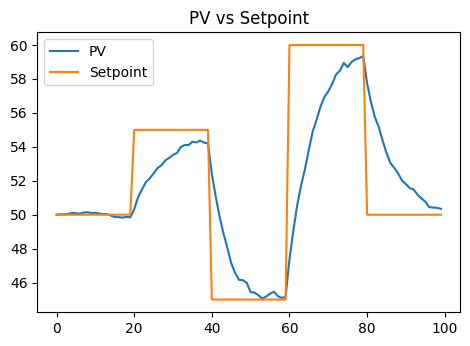

In [ ]:
# Configurações
np.random.seed(42)
n_points = 100

# Geração do setpoint com 4 regimes diferentes
setpoint = np.full(n_points, 50)
setpoint[20:40] = 55    # Primeira mudança de SP
setpoint[40:60] = 45    # Segunda mudança (regime inverso)
setpoint[60:80] = 60    # Terceira mudança (mais agressiva)
setpoint[80:] = 50      # Retorno ao valor inicial

# Simulação da Variável do Processo (PV) com dinâmica de sistema
PV = np.zeros(n_points)
PV[0] = 50
tau = 5  # Constante de tempo do sistema
dt = 1   # Intervalo de amostragem

# Simulação com diferentes condições operacionais
for t in range(1, n_points):
    if t < 20:
        PV[t] = PV[t-1] + 0.8*(setpoint[t] - PV[t-1])*dt/tau + np.random.normal(0, 0.05)
    elif 20 <= t < 40:
        PV[t] = PV[t-1] + 0.6*(setpoint[t] - PV[t-1])*dt/tau + np.random.normal(0, 0.1)
    elif 40 <= t < 60:
        PV[t] = PV[t-1] + 1.0*(setpoint[t] - PV[t-1])*dt/tau + np.random.normal(0, 0.2)
    else:
        PV[t] = PV[t-1] + 0.7*(setpoint[t] - PV[t-1])*dt/tau + np.random.normal(0, 0.15)

# Geração da Variável Manipulada (MV) com lógica de controle especialista
MV = np.zeros(n_points)
MV[0] = 30

for t in range(1, n_points):
    erro = setpoint[t] - PV[t]
    derivada_erro = (erro - (setpoint[t-1] - PV[t-1]))

    # Lógica de controle baseada em regras (o julgamento do operador)
    if abs(erro) > 2:
        MV[t] = MV[t-1] + 0.5 * erro + 0.2 * derivada_erro
    elif abs(derivada_erro) > 0.5:
        MV[t] = MV[t-1] + 0.3 * erro + 0.4 * derivada_erro
    else:
        MV[t] = MV[t-1] + 0.1 * erro

    MV[t] = np.clip(MV[t], 20, 60)  # Saturação da ação de controle

# Cálculos derivados
erro = [setpoint[t] - PV[t] for t in range(n_points)]
derivada_erro = [0.0] + [erro[t] - erro[t-1] for t in range(1, n_points)]
variacao_MV = [0] + [MV[t] - MV[t-1] for t in range(1, n_points)]

# Plot dos dados
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(PV, label='PV')
plt.plot(setpoint, label='Setpoint')
plt.title('PV vs Setpoint')
plt.legend()

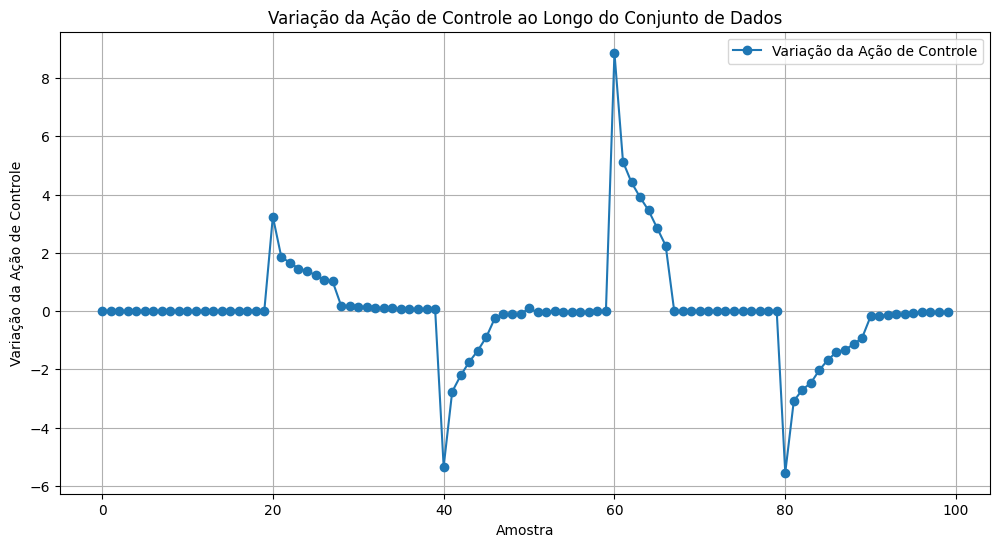

In [ ]:
#Ver variação da ação de controle ao longo do conjunto de dados
plt.figure(figsize=(12, 6))
plt.plot(variacao_MV, label='Variação da Ação de Controle', marker='o')
plt.title('Variação da Ação de Controle ao Longo do Conjunto de Dados')
plt.ylabel('Variação da Ação de Controle')
plt.xlabel('Amostra')
plt.legend()
plt.grid(True)
plt.show()

### Mapeamento com base nas qualificações das variaveis

RMSE: 1.10


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/skfuzzy/control/fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


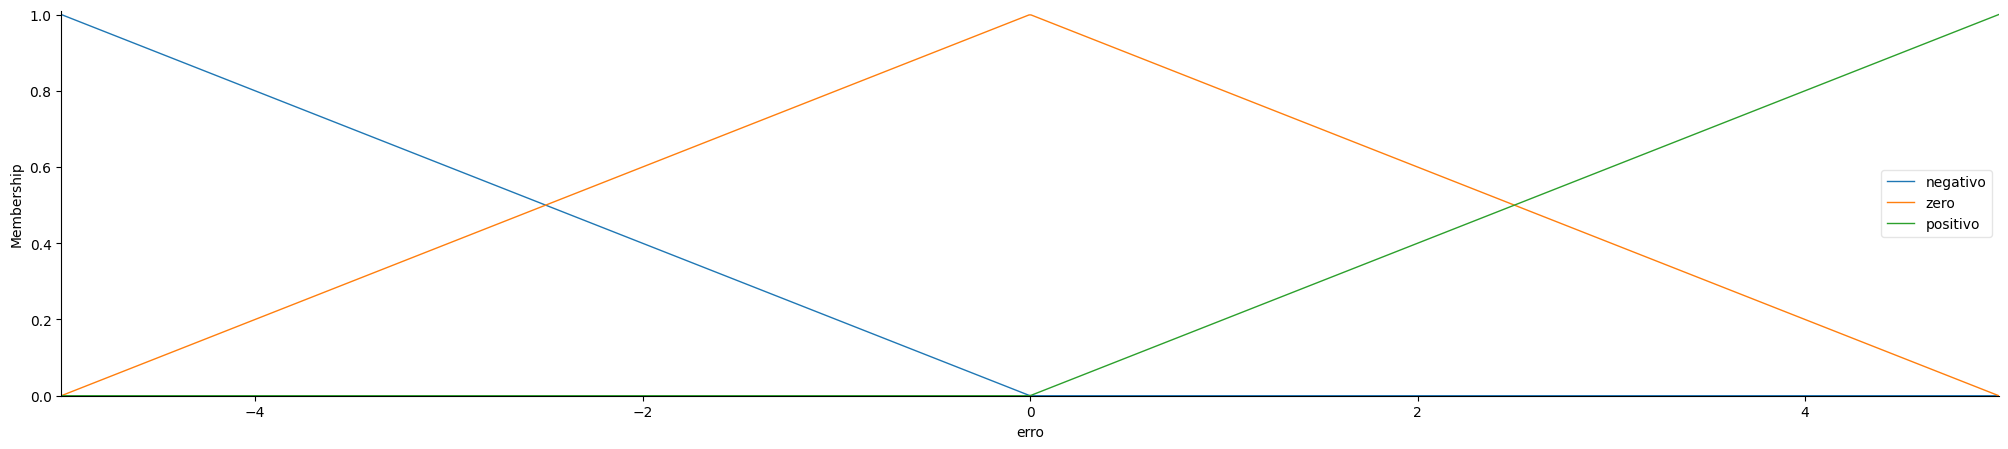

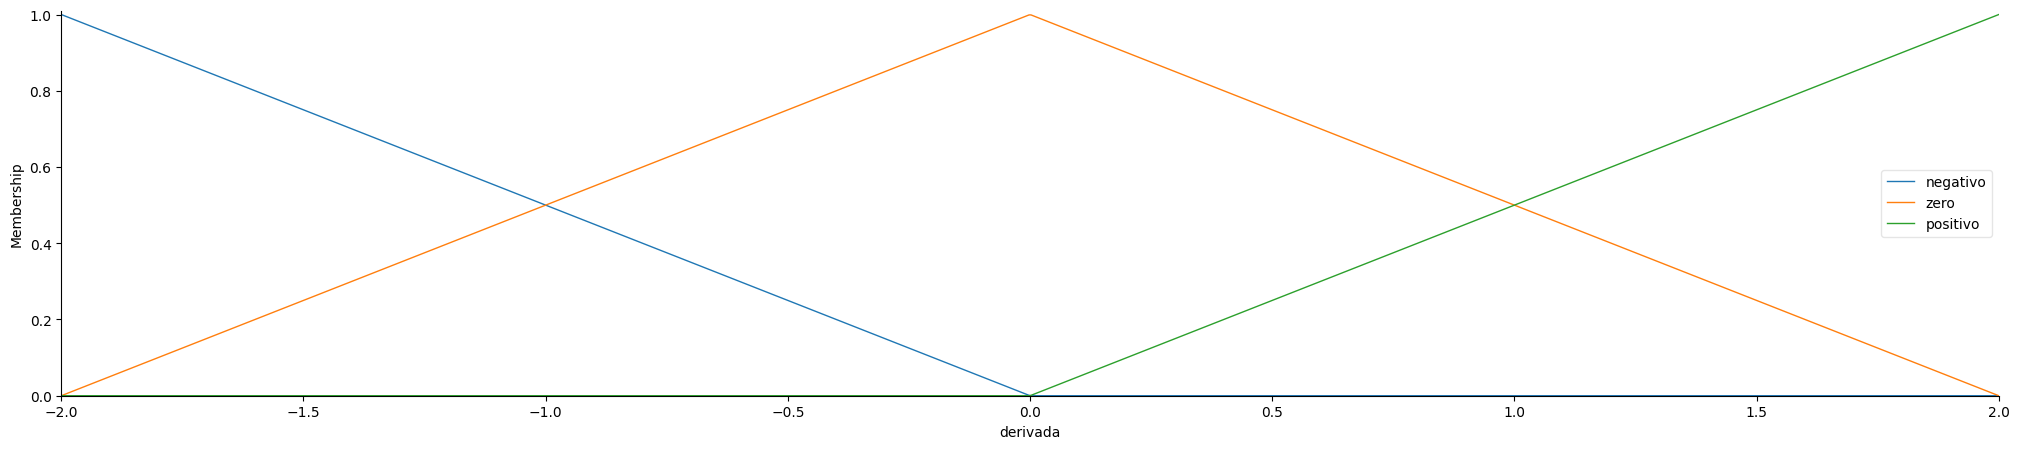

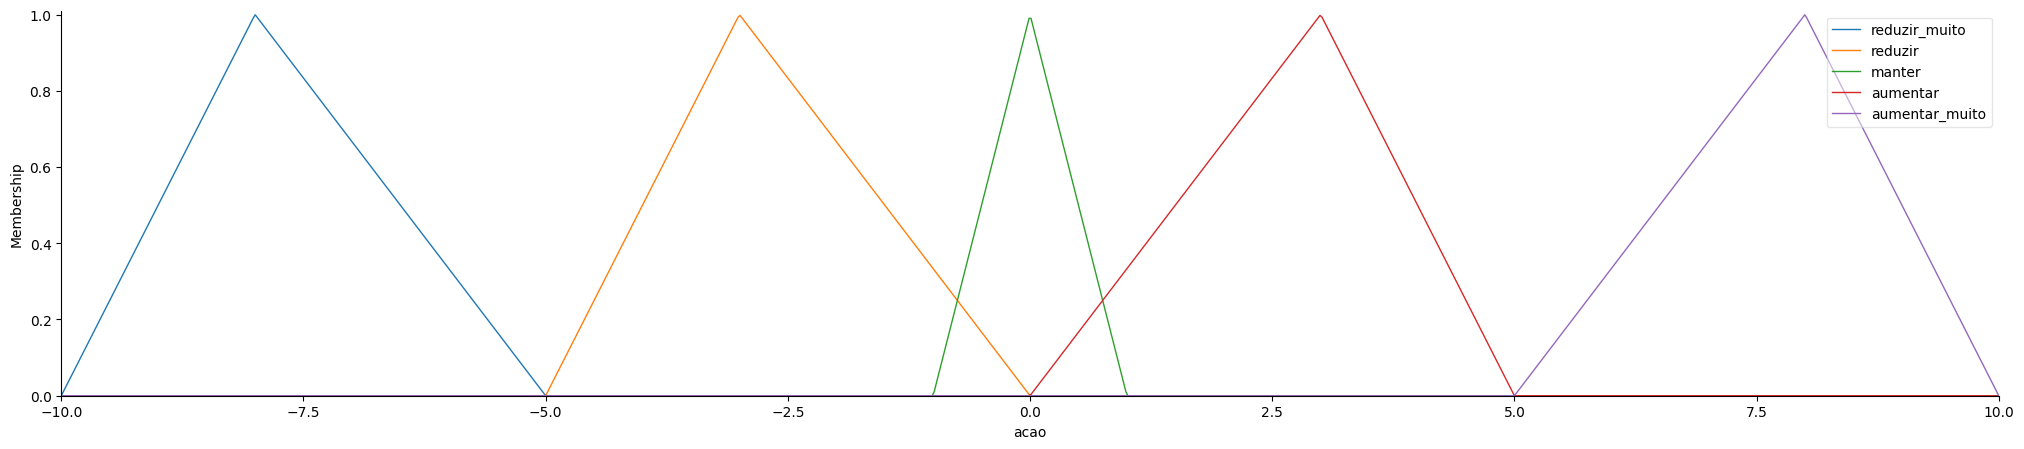

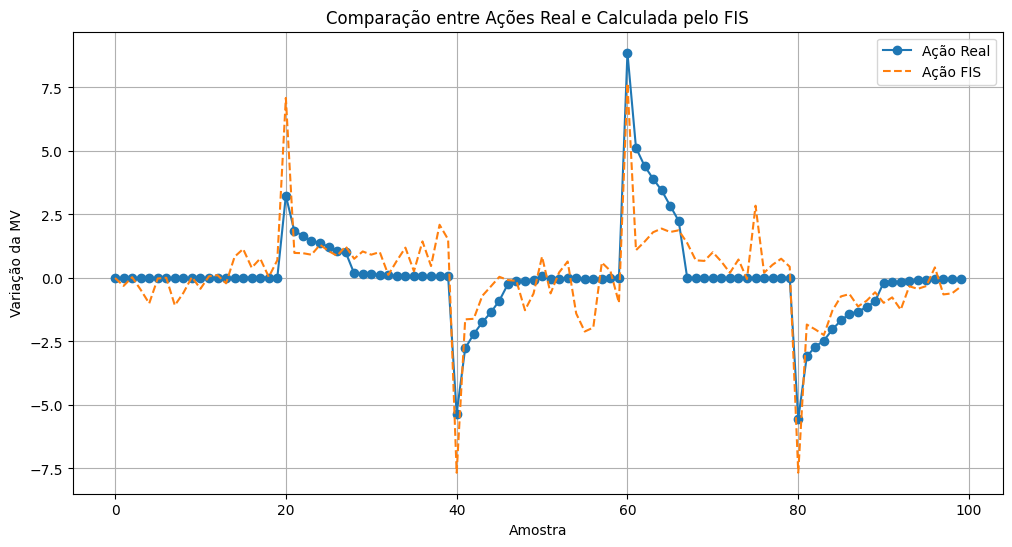

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Carregar os dados gerados anteriormente
# (Usando as variáveis do código anterior)
erro = np.array(erro)
derivada_erro = np.array(derivada_erro)
variacao_MV = np.array(variacao_MV)

# Definir universo de discurso
erro_range = np.linspace(-5, 5, 1000)
derivada_range = np.linspace(-2, 2, 1000)
acao_range = np.linspace(-10, 10, 1000)

# Criar variáveis fuzzy
erro_input = ctrl.Antecedent(erro_range, 'erro')
derivada_input = ctrl.Antecedent(derivada_range, 'derivada')
acao_output = ctrl.Consequent(acao_range, 'acao')

# Definir funções de pertinência automáticas com ajuste aos dados
erro_input.automf(3, names=['negativo', 'zero', 'positivo'])
derivada_input.automf(3, names=['negativo', 'zero', 'positivo'])

# Funções de pertinência personalizadas para a ação
acao_output['reduzir_muito'] = fuzz.trimf(acao_range, [-10, -8, -5])
acao_output['reduzir'] = fuzz.trimf(acao_range, [-5, -3, 0])
acao_output['manter'] = fuzz.trimf(acao_range, [-1, 0, 1])
acao_output['aumentar'] = fuzz.trimf(acao_range, [0, 3, 5])
acao_output['aumentar_muito'] = fuzz.trimf(acao_range, [5, 8, 10])

# Regras fuzzy baseadas no comportamento observado do operador
regras = [
    ctrl.Rule(erro_input['negativo'] & derivada_input['negativo'], acao_output['reduzir_muito']),
    ctrl.Rule(erro_input['negativo'] & derivada_input['zero'], acao_output['reduzir']),
    ctrl.Rule(erro_input['negativo'] & derivada_input['positivo'], acao_output['manter']),
    ctrl.Rule(erro_input['zero'] & derivada_input['negativo'], acao_output['reduzir']),
    ctrl.Rule(erro_input['zero'] & derivada_input['zero'], acao_output['manter']),
    ctrl.Rule(erro_input['zero'] & derivada_input['positivo'], acao_output['aumentar']),
    ctrl.Rule(erro_input['positivo'] & derivada_input['negativo'], acao_output['manter']),
    ctrl.Rule(erro_input['positivo'] & derivada_input['zero'], acao_output['aumentar']),
    ctrl.Rule(erro_input['positivo'] & derivada_input['positivo'], acao_output['aumentar_muito'])
]

# Criar e simular sistema de controle
sistema_controle = ctrl.ControlSystem(regras)
sistema_simulacao = ctrl.ControlSystemSimulation(sistema_controle)

# Rodando SIF usando os dados históricos
acoes_calculadas = []
for i in range(len(erro)):
    sistema_simulacao.input['erro'] = erro[i]
    sistema_simulacao.input['derivada'] = derivada_erro[i]
    sistema_simulacao.compute()
    acoes_calculadas.append(sistema_simulacao.output['acao'])

# Calcular erro de ajuste
rmse = np.sqrt(mean_squared_error(variacao_MV, acoes_calculadas))
print(f'RMSE: {rmse:.2f}')

# Visualização do SIF
erro_input.view()
derivada_input.view()
acao_output.view()

# Comparação entre ações real e calculada
plt.figure(figsize=(12, 6))
plt.plot(variacao_MV, label='Ação Real', marker='o')
plt.plot(acoes_calculadas, label='Ação FIS', linestyle='--')
plt.title('Comparação entre Ações Real e Calculada pelo FIS')
plt.ylabel('Variação da MV')
plt.xlabel('Amostra')
plt.legend()
plt.grid(True)
plt.show()

### Mapeamento com ajuste de dados

In [ ]:
!pip install deap

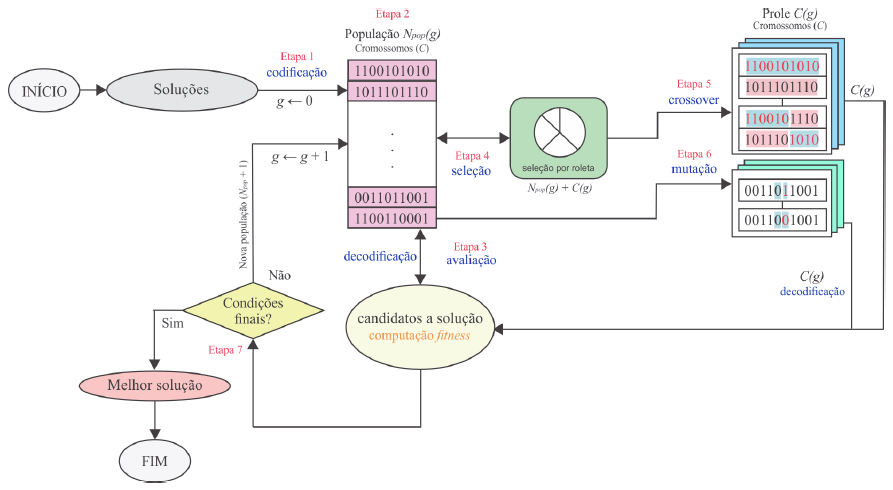

gen	nevals	avg	min    
0  	100   	inf	1.36601
1  	82    	inf	1.332  
2  	82    	inf	1.24724
3  	88    	inf	1.24345
4  	90    	inf	1.29076
5  	81    	inf	1.0391 
6  	82    	inf	0.972845
7  	85    	inf	0.819416
8  	88    	inf	0.819416
9  	79    	inf	0.819416
10 	86    	inf	1.12927 
11 	90    	inf	0.919714
12 	75    	inf	0.919714
13 	91    	inf	0.919714
14 	76    	inf	0.867455
15 	92    	inf	0.873769
16 	71    	inf	0.853652
17 	86    	inf	0.86866 
18 	88    	inf	0.769438
19 	90    	inf	0.765473
20 	85    	inf	0.783272
21 	86    	inf	0.802965
22 	88    	inf	0.791904
23 	79    	inf	0.714195
24 	89    	inf	0.705801
25 	89    	inf	0.696213
26 	88    	inf	0.696213
27 	85    	inf	0.717165
28 	83    	inf	0.691874
29 	79    	inf	0.691874
30 	88    	inf	0.693384
31 	81    	inf	0.651706
32 	90    	inf	0.649636
33 	89    	inf	0.660151
34 	74    	inf	0.646944
35 	82    	inf	0.635885
36 	86    	inf	0.608362
37 	85    	inf	0.628814
38 	77    	inf	0.611102
39 	75    	inf	0.600408
40 	87    	inf	0.595764

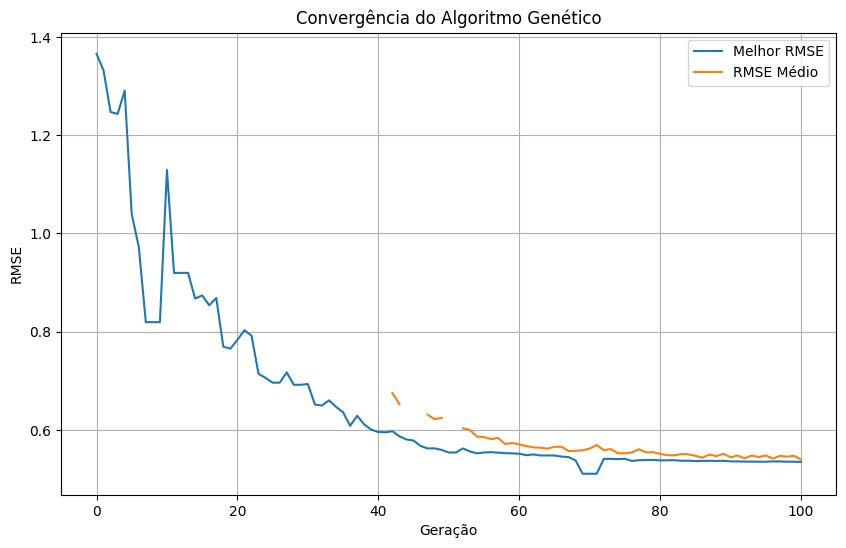

In [ ]:
# Importação das bibliotecas necessárias
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from deap import base, creator, tools, algorithms
import random
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Dados previamente definidos (vetores): erro do controlador, derivada do erro e variação desejada (dados reais)
erro = np.array(erro)
derivada_erro = np.array(derivada_erro)
variacao_MV = np.array(variacao_MV)

# Definição dos intervalos de entrada (erro, derivada_erro) e saída (ação)
erro_range = (-5, 5)
derivada_range = (-2, 2)
acao_range = (-10, 10)

# Configuração dos parâmetros do Algoritmo Genético (GA)
POP_SIZE = 100            # Número de indivíduos na população
NGEN = 100                # Número de gerações que o algoritmo rodará
CXPB = 0.8                # Probabilidade de crossover (recombinação entre indivíduos)
MUTPB = 0.2               # Probabilidade de mutação nos genes individuais

# Configuração da estrutura que o GA irá minimizar ("weights=(-1.0,)" indica minimização)
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()

# Função para gerar parâmetros aleatórios dentro dos intervalos estabelecidos
def random_param(param_range):
    return random.uniform(param_range[0], param_range[1])

# Registro de funções geradoras aleatórias para criar os genes individuais
toolbox.register("attr_erro", random_param, erro_range)
toolbox.register("attr_derivada", random_param, derivada_range)
toolbox.register("attr_acao", random_param, acao_range)

# Criação dos indivíduos: cada indivíduo é composto por 45 genes (parâmetros das funções fuzzy)
# (3 MFs para erro x 3 parâmetros cada + 3 MFs para derivada x 3 parâmetros + 5 MFs para ação x 3 parâmetros = 45 genes)
toolbox.register("individual", tools.initCycle, creator.Individual,
                 (toolbox.attr_erro, toolbox.attr_derivada, toolbox.attr_acao), n=15)

# Gerador da população inicial
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Função objetivo que avalia o desempenho (fitness) do indivíduo através do RMSE
def evaluate(individual):
    try:
        # Construção dinâmica (a cada avaliação) do sistema fuzzy com parâmetros do indivíduo atual
        erro_input = ctrl.Antecedent(np.linspace(*erro_range, 100), 'erro')
        derivada_input = ctrl.Antecedent(np.linspace(*derivada_range, 100), 'derivada')
        acao_output = ctrl.Consequent(np.linspace(*acao_range, 100), 'acao')

        # Parâmetros para funções de pertinência do erro (3 funções: negativo, zero, positivo)
        erro_mfs = [sorted(individual[i:i+3]) for i in [0, 3, 6]]
        for i, name in enumerate(['negativo', 'zero', 'positivo']):
            erro_input[name] = fuzz.trimf(erro_input.universe, erro_mfs[i])

        # Parâmetros para funções de pertinência da derivada do erro (3 funções)
        derivada_mfs = [sorted(individual[i:i+3]) for i in [9, 12, 15]]
        for i, name in enumerate(['negativo', 'zero', 'positivo']):
            derivada_input[name] = fuzz.trimf(derivada_input.universe, derivada_mfs[i])

        # Parâmetros para funções de pertinência da ação de controle (5 funções fuzzy)
        acao_mfs = [sorted(individual[i:i+3]) for i in [18, 21, 24, 27, 30]]
        names_acao = ['reduzir_muito', 'reduzir', 'manter', 'aumentar', 'aumentar_muito']
        for i, name in enumerate(names_acao):
            acao_output[name] = fuzz.trimf(acao_output.universe, acao_mfs[i])

        # Definição das regras fuzzy fixas para o controlador:
        regras = [
            ctrl.Rule(erro_input['negativo'] & derivada_input['negativo'], acao_output['reduzir_muito']),
            ctrl.Rule(erro_input['negativo'] & derivada_input['zero'], acao_output['reduzir']),
            ctrl.Rule(erro_input['negativo'] & derivada_input['positivo'], acao_output['manter']),
            ctrl.Rule(erro_input['zero'] & derivada_input['negativo'], acao_output['reduzir']),
            ctrl.Rule(erro_input['zero'] & derivada_input['zero'], acao_output['manter']),
            ctrl.Rule(erro_input['zero'] & derivada_input['positivo'], acao_output['aumentar']),
            ctrl.Rule(erro_input['positivo'] & derivada_input['negativo'], acao_output['manter']),
            ctrl.Rule(erro_input['positivo'] & derivada_input['zero'], acao_output['aumentar']),
            ctrl.Rule(erro_input['positivo'] & derivada_input['positivo'], acao_output['aumentar_muito'])
        ]

        # Geração do sistema fuzzy e simulação para obter previsões da ação do controlador
        sistema = ctrl.ControlSystem(regras)
        simulador = ctrl.ControlSystemSimulation(sistema)

        predicoes = []
        for e, d in zip(erro, derivada_erro):
            simulador.input['erro'] = e
            simulador.input['derivada'] = d
            simulador.compute()
            predicoes.append(simulador.output['acao'])

        # RMSE entre valores verdadeiros e valores previstos pelo controlador fuzzy
        rmse = np.sqrt(mean_squared_error(variacao_MV, predicoes))
        return (rmse,)
    except:
        # Em caso de erro numérico/matemático ou parâmetros inválidos, penaliza fortemente o indivíduo
        return (float('inf'),)

# Registro das funções genéticas padrão: avaliação, recombinação (mate), mutação e seleção
toolbox.register("evaluate", evaluate)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=0.5, indpb=0.1)
toolbox.register("select", tools.selTournament, tournsize=3)

# Função para executar a otimização por algoritmo genético
def optimizar_fis():
    pop = toolbox.population(n=POP_SIZE)
    hof = tools.HallOfFame(1) # salva o melhor indivíduo
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("min", np.min)

    pop, log = algorithms.eaSimple(pop, toolbox, cxpb=CXPB, mutpb=MUTPB, ngen=NGEN,
                                   stats=stats, halloffame=hof, verbose=True)
    return hof[0], log

# Execução da otimização
best_ind, log = optimizar_fis()

# Apresentação do melhor indivíduo encontrado após a otimização
print("\nMelhores parâmetros encontrados:")
print(f"Erro MFs: {best_ind[0:9]}")
print(f"Derivada MFs: {best_ind[9:18]}")
print(f"Ação MFs: {best_ind[18:33]}")

# Gráfico mostrando convergência do RMSE durante as gerações do algoritmo
plt.figure(figsize=(10,6))
plt.plot(log.select('min'), label='Melhor RMSE')
plt.plot(log.select('avg'), label='RMSE Médio')
plt.xlabel('Geração')
plt.ylabel('RMSE')
plt.title('Convergência do Algoritmo Genético')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Reconstruir o FIS com os melhores parâmetros
best_erro_mfs = [sorted(best_ind[i:i+3]) for i in [0,3,6]]
best_derivada_mfs = [sorted(best_ind[i:i+3]) for i in [9,12,15]]
best_acao_mfs = [sorted(best_ind[i:i+3]) for i in [18,21,24,27,30]]

# Extração dos parâmetros do cromossomo
# Membership functions para erro
for i, name in enumerate(['negativo', 'zero', 'positivo']):
    erro_input[name] = fuzz.trimf(erro_input.universe, best_erro_mfs[i])

# Membership functions para derivada
for i, name in enumerate(['negativo', 'zero', 'positivo']):
    derivada_input[name] = fuzz.trimf(derivada_input.universe, best_derivada_mfs[i])

# Membership functions para ação
names_acao = ['reduzir_muito', 'reduzir', 'manter', 'aumentar', 'aumentar_muito']
for i, name in enumerate(names_acao):
    acao_output[name] = fuzz.trimf(acao_output.universe, best_acao_mfs[i])

# (Usar a mesma estrutura de criação do FIS do código anterior com estes parâmetros)
# Regras de controle fixas
regras = [
    ctrl.Rule(erro_input['negativo'] & derivada_input['negativo'], acao_output['reduzir_muito']),
    ctrl.Rule(erro_input['negativo'] & derivada_input['zero'], acao_output['reduzir']),
    ctrl.Rule(erro_input['negativo'] & derivada_input['positivo'], acao_output['manter']),
    ctrl.Rule(erro_input['zero'] & derivada_input['negativo'], acao_output['reduzir']),
    ctrl.Rule(erro_input['zero'] & derivada_input['zero'], acao_output['manter']),
    ctrl.Rule(erro_input['zero'] & derivada_input['positivo'], acao_output['aumentar']),
    ctrl.Rule(erro_input['positivo'] & derivada_input['negativo'], acao_output['manter']),
    ctrl.Rule(erro_input['positivo'] & derivada_input['zero'], acao_output['aumentar']),
    ctrl.Rule(erro_input['positivo'] & derivada_input['positivo'], acao_output['aumentar_muito'])
]

sistema = ctrl.ControlSystem(regras)
simulador = ctrl.ControlSystemSimulation(sistema)

#Rodar os dados e armazenar em acoes_genetico
acoes_genetico = []
for e, d in zip(erro, derivada_erro):
    simulador.input['erro'] = e
    simulador.input['derivada'] = d
    simulador.compute()
    acoes_genetico.append(simulador.output['acao'])

# Comparar desempenho antes/depois
print(f'RMSE inicial: {evaluate(toolbox.individual())[0]:.4f}')
print(f'RMSE otimizado: {evaluate(best_ind)[0]:.4f}')

RMSE inicial: inf
RMSE otimizado: 0.5108


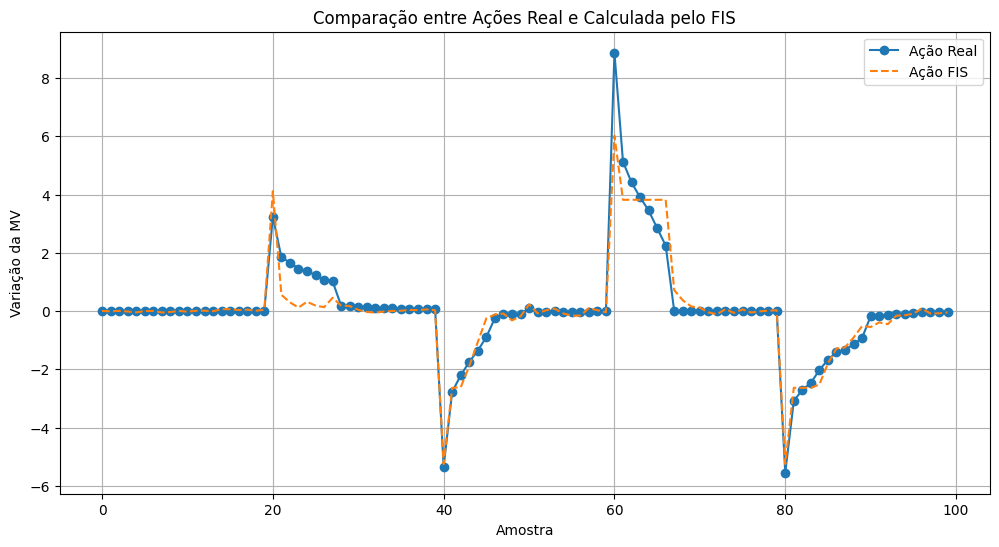

In [ ]:
# Comparação entre ações real e calculada
plt.figure(figsize=(12, 6))
plt.plot(variacao_MV, label='Ação Real', marker='o')
plt.plot(acoes_genetico, label='Ação FIS', linestyle='--')
plt.title('Comparação entre Ações Real e Calculada pelo FIS')
plt.ylabel('Variação da MV')
plt.xlabel('Amostra')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Usar os dados gerados anteriormente
erro = np.array(erro)
derivada_erro = np.array(derivada_erro)
variacao_MV = np.array(variacao_MV)

# Fundamentação Teórica: Otimização Híbrida de Sistemas Neuro-Fuzzy (ANFIS)

Este algoritmo implementa uma variação robusta do **ANFIS** (*Adaptive Neuro-Fuzzy Inference System*), projetada para extrair regras de controle a partir de dados históricos, mitigando problemas de instabilidade numérica comuns em métodos de mínimos quadrados puros.

O processo é fundamentado em três pilares: **Estrutura Takagi-Sugeno**, **Otimização Híbrida** e **Regularização Ridge**.

---

## 1. Pré-processamento e Normalização

A primeira etapa trata os dados brutos de entrada (`erro` e `derivada`).

* **Problema:** Algoritmos de otimização baseados em gradiente (como o `L-BFGS-B` utilizado) têm dificuldade de convergência quando as variáveis de entrada possuem escalas muito distintas (ex: erro variando de -5 a 5 e derivada de -0.1 a 0.1).
* **Solução:** A função `normalize` mapeia todas as entradas para o intervalo $[0, 1]$.
    $$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$$
    Isso cria um "terreno de busca" uniforme (isotrópico) para o algoritmo encontrar os melhores parâmetros.

---

## 2. A Estrutura Neuro-Fuzzy (Takagi-Sugeno)

O código implementa um sistema Fuzzy do tipo **Takagi-Sugeno de Ordem 1**. Diferente do método de Mamdani (cujo consequente é um conjunto fuzzy), o Takagi-Sugeno responde com uma **equação linear**.

### A. Antecedentes (A parte "Fuzzy")
O sistema classifica as entradas em conceitos linguísticos (ex: "Erro Pequeno", "Erro Grande").
* **Função de Pertinência:** Utilizamos Gaussianas devido à sua suavidade e diferenciabilidade.
    $$\mu(x) = e^{-0.5 (\frac{x - c}{\sigma})^2}$$
    * **$c$ (Centro):** O local onde a pertinência é máxima.
    * **$\sigma$ (Sigma):** O desvio padrão, representando a largura ou abrangência do conceito.
* **Otimização:** O vetor `self.params` contém todos os $c$ e $\sigma$ que o otimizador ajustará para "encaixar" as curvas aos dados.

### B. Consequentes (A parte "Matemática")
Para cada regra possível (ex: *SE Erro é Alto E Derivada é Baixa*), o sistema gera uma saída linear:
$$y_i = a_i \cdot \text{Erro} + b_i \cdot \text{Derivada} + k_i$$
O objetivo é descobrir os coeficientes ótimos $a, b, k$ para todas as regras simultaneamente.

---

## 3. Otimização Híbrida (O "Cérebro" do Código)

Utilizamos um método híbrido que separa o problema em duas partes: **Não-Linear** (curvas) e **Linear** (retas de saída).

### Passo 1: O "Passo Forward" (Não-Linear)
Calcula-se a **Matriz de Ativação ($A$)**:
1.  Calcula-se o grau de pertinência ($\mu$) de cada dado nas curvas atuais.
2.  Calcula-se o **peso de disparo** ($w$) de cada regra (T-Norma Produto).
3.  Normaliza-se o peso ($\bar{w}$) para que a soma de todas as regras seja 1.
4.  Monta-se a matriz onde cada linha representa a contribuição das entradas ponderadas pelo peso da regra:
    $$\text{Linha}_A = [\bar{w} \cdot E, \quad \bar{w} \cdot D, \quad \bar{w}]$$

### Passo 2: Regularização Ridge (A Solução do Pico)
Aqui corrigimos o problema de *overfitting* (picos gigantes na saída). O método clássico tenta resolver $A \cdot \theta = Y$. Se a matriz $A$ tiver valores próximos de zero (nenhuma regra ativada), o computador gera coeficientes gigantescos para compensar.

* **Solução (Ridge Regression):** Adicionamos uma penalidade ($\alpha$) na diagonal da matriz para garantir estabilidade numérica.
    $$\theta = (A^T A + \alpha I)^{-1} A^T Y$$
    * **$I$**: Matriz identidade.
    * **$\alpha$**: Fator de regularização (no código, `ridge_alpha`).
* **Efeito:** Impede que os coeficientes explodam, garantindo uma superfície de controle suave.

### Passo 3: O Loop de Otimização (L-BFGS-B)
O otimizador `scipy.optimize.minimize` ajusta apenas os **Antecedentes** (Centros e Sigmas):
1.  O algoritmo "chuta" posições para as curvas gaussianas.
2.  Chama a `objective_function`.
3.  A função calcula internamente os melhores consequentes (usando Ridge) para aquele chute e retorna o erro (MSE).
4.  O otimizador ajusta o chute na direção que diminui o erro até convergir.

---

## 4. Fluxo de Inferência (Uso Prático)

Para utilizar o modelo treinado em novos dados:

1.  **Normalização:** O dado cru é normalizado usando os mesmos máximos e mínimos do conjunto de treino.
2.  **Pertinência:** Calcula-se a pertinência nas gaussianas otimizadas (`self.params`).
3.  **Ativação:** Calcula-se o peso das regras.
4.  **Cálculo Linear:** Multiplica-se a ativação pelos coeficientes lineares (`self.consequents`) encontrados via Ridge.
5.  **Soma:** A soma ponderada resulta na variação da MV.

Treinando modelo robusto...
Treinamento Concluído. RMSE Final: 0.2560


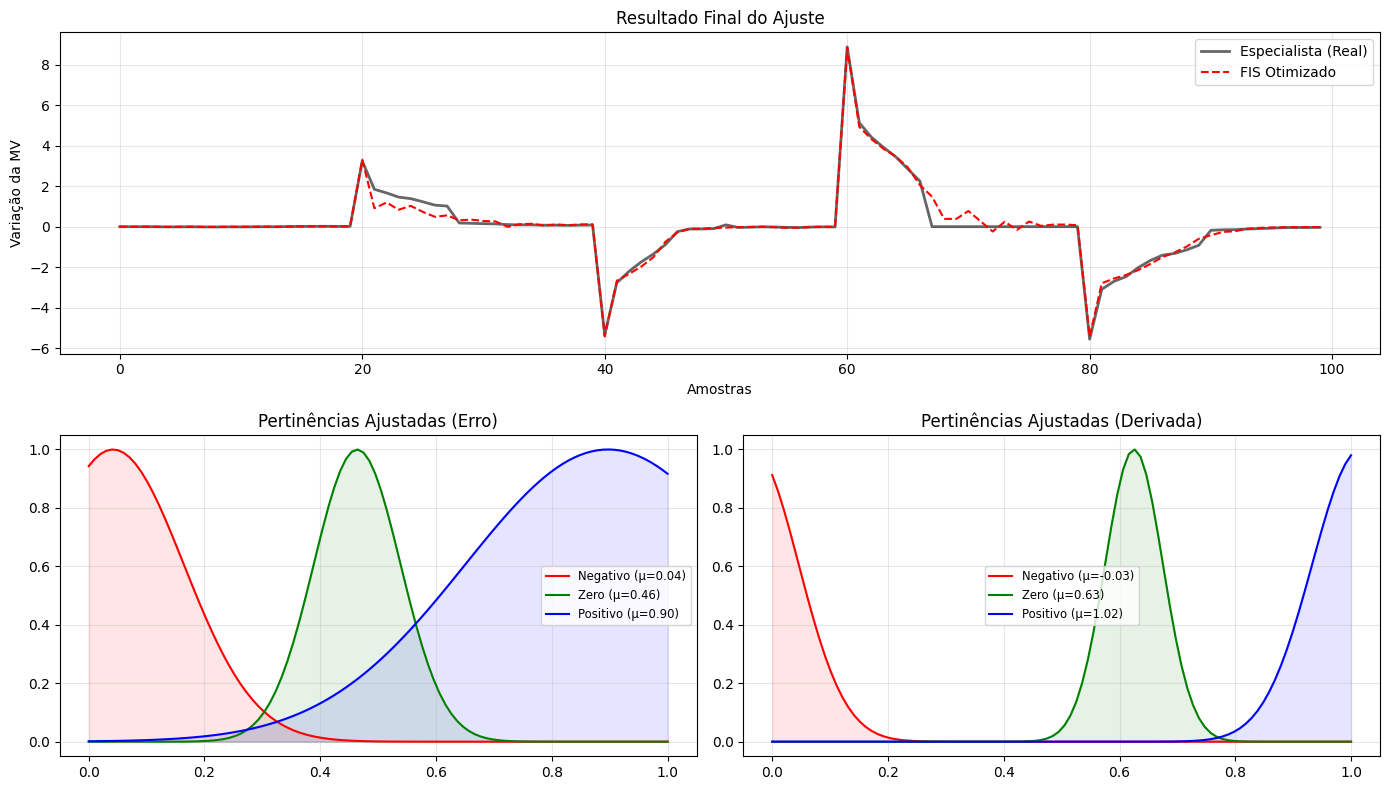

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings

# Ignorar warnings irrelevantes durante o loop de otimização
warnings.filterwarnings('ignore')

# ==============================================================================
# 1. PREPARAÇÃO DOS DADOS (Mantendo os seus dados)
# ==============================================================================
def normalize(x):
    return (x - np.min(x)) / (np.max(x) - np.min(x))

E_norm = normalize(erro)
D_norm = normalize(derivada_erro)
Y_target = variacao_MV

# ==============================================================================
# 2. CLASSE ROBUSTA ANFIS (Versão Estável)
# ==============================================================================

class StableANFIS:
    def __init__(self, n_mf=3, ridge_alpha=0.01):
        self.n_mf = n_mf
        self.ridge_alpha = ridge_alpha

        # Inicialização inteligente: Centros distribuídos e Sigmas seguros
        centers = np.linspace(0, 1, n_mf)
        sigmas = np.ones(n_mf) * 0.2  # Começa largo para cobrir os dados

        # [centros_erro, sigmas_erro, centros_deriv, sigmas_deriv]
        self.params = np.concatenate([centers, sigmas, centers, sigmas])
        self.consequents = None

    def gaussian(self, x, mu, sigma):
        # Proteção: Sigma nunca pode ser zero absoluto
        safe_sigma = np.maximum(sigma, 1e-4)
        return np.exp(-0.5 * ((x - mu) / safe_sigma)**2)

    def get_matrix_A(self, e, d, params):
        """Gera matriz de regressão com proteções numéricas"""
        n = self.n_mf
        mu_e = params[0:n]
        sig_e = params[n:2*n]
        mu_d = params[2*n:3*n]
        sig_d = params[3*n:4*n]

        A_rows = []
        for i in range(len(e)):
            m_e = self.gaussian(e[i], mu_e, sig_e)
            m_d = self.gaussian(d[i], mu_d, sig_d)

            # Produto Cartesiano das regras
            w = np.outer(m_e, m_d).flatten()

            # Proteção contra soma zero (se nenhuma regra ativar)
            w_sum = np.sum(w)
            if w_sum < 1e-10:
                w_norm = np.zeros_like(w)
            else:
                w_norm = w / w_sum

            # Construção da linha (TS Ordem 1)
            row = []
            for wk in w_norm:
                row.extend([wk * e[i], wk * d[i], wk])
            A_rows.append(row)

        return np.array(A_rows)

    def objective_function(self, params_ant):
        # 1. Gera Matriz de Ativação
        A = self.get_matrix_A(E_norm, D_norm, params_ant)

        # 2. Verificação de Sanidade (Se A tiver NaN, penaliza imediatamente)
        if not np.all(np.isfinite(A)):
            return 1e9 # Retorna erro gigante para o otimizador fugir daqui

        # 3. Ridge Regression (L2 Regularization) para Consequentes
        # Resolve (A.T*A + alpha*I)*Theta = A.T*Y
        try:
            n_vars = A.shape[1]
            # Matriz de Identidade multiplicada pelo fator de regularização
            I = np.eye(n_vars) * self.ridge_alpha

            # Parte esquerda da equação linear
            XtX = A.T @ A + I
            XtY = A.T @ Y_target

            # Resolve sistema linear
            theta = np.linalg.solve(XtX, XtY)

            # 4. Cálculo do Erro
            y_pred = A @ theta
            mse = np.mean((Y_target - y_pred)**2)

            # Armazena temporariamente
            self.temp_theta = theta
            return mse

        except np.linalg.LinAlgError:
            # Se a matriz for singular (impossível inverter), penaliza
            return 1e9

    def train(self):
        print("Treinando modelo robusto...")

        # Restrições: Centros podem passar um pouco de 0 e 1, Sigmas não podem ser zero
        # Formato: [(min, max), ...] para cada parâmetro
        n = self.n_mf
        bounds_centers = [(-0.2, 1.2)] * n
        bounds_sigmas = [(0.05, 1.0)] * n # Sigma mínimo de 0.05 evita "agulhas"

        all_bounds = bounds_centers + bounds_sigmas + bounds_centers + bounds_sigmas

        res = minimize(
            self.objective_function,
            self.params,
            method='L-BFGS-B',
            bounds=all_bounds,
            options={'maxiter': 100, 'ftol': 1e-5}
        )

        self.params = res.x
        self.consequents = self.temp_theta
        print(f"Treinamento Concluído. RMSE Final: {np.sqrt(res.fun):.4f}")

    def predict(self, e, d):
        A = self.get_matrix_A(e, d, self.params)
        return A @ self.consequents

# ==============================================================================
# 3. EXECUÇÃO
# ==============================================================================

# Ridge alpha = 0.01 permite um ajuste fino sem deixar os números explodirem
model = StableANFIS(n_mf=3, ridge_alpha=0.01)
model.train()
y_pred = model.predict(E_norm, D_norm)

# ==============================================================================
# 4. VISUALIZAÇÃO
# ==============================================================================
plt.figure(figsize=(14, 8))

# Gráfico Principal
plt.subplot(2, 2, (1, 2))
plt.plot(Y_target, 'k-', alpha=0.6, label='Especialista (Real)', linewidth=2)
plt.plot(y_pred, 'r--', label='FIS Otimizado')
plt.title(f'Resultado Final do Ajuste')
plt.ylabel('Variação da MV')
plt.xlabel('Amostras')
plt.legend()
plt.grid(True, alpha=0.3)

# Funções de Pertinência de ERRO
plt.subplot(2, 2, 3)
x_axis = np.linspace(0, 1, 100)
# Desempacotar parâmetros finais
mu_e = model.params[0:3]
sig_e = model.params[3:6]
labels = ['Negativo', 'Zero', 'Positivo']
colors = ['red', 'green', 'blue']

for i in range(3):
    y = model.gaussian(x_axis, mu_e[i], sig_e[i])
    plt.plot(x_axis, y, color=colors[i], label=f'{labels[i]} (µ={mu_e[i]:.2f})')
    plt.fill_between(x_axis, 0, y, color=colors[i], alpha=0.1)
plt.title('Pertinências Ajustadas (Erro)')
plt.legend(fontsize='small')
plt.grid(True, alpha=0.3)

# Funções de Pertinência de DERIVADA
plt.subplot(2, 2, 4)
mu_d = model.params[6:9]
sig_d = model.params[9:12]
for i in range(3):
    y = model.gaussian(x_axis, mu_d[i], sig_d[i])
    plt.plot(x_axis, y, color=colors[i], label=f'{labels[i]} (µ={mu_d[i]:.2f})')
    plt.fill_between(x_axis, 0, y, color=colors[i], alpha=0.1)
plt.title('Pertinências Ajustadas (Derivada)')
plt.legend(fontsize='small')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# --- SIMULAÇÃO DE USO EM TEMPO REAL ---

# 1. Novos dados chegando da planta (Exemplo)
novo_erro = 2.5       # Erro positivo médio
nova_derivada = -0.5  # Derivada negativa (erro diminuindo)

E_min, E_max = np.min(erro), np.max(erro)
D_min, D_max = np.min(derivada_erro), np.max(derivada_erro)

# 2. Normalização (Usando os min/max dos dados de TREINO)
# É fundamental usar as variáveis E_min, E_max, etc. calculadas lá no início
e_input = (novo_erro - E_min) / (E_max - E_min)
d_input = (nova_derivada - D_min) / (D_max - D_min)

# O predict espera arrays, então colocamos em listas [ ]
# Se tiver vários pontos, passe listas maiores
e_input_arr = np.array([e_input])
d_input_arr = np.array([d_input])

# 3. Cálculo da Ação
acao_mv = model.predict(e_input_arr, d_input_arr)

print(f"Situação: Erro={novo_erro}, Derivada={nova_derivada}")
print(f"Ação Recomendada pelo Fuzzy: {acao_mv[0]:.4f}")

Situação: Erro=2.5, Derivada=-0.5
Ação Recomendada pelo Fuzzy: 0.2022
